In [1]:
!pip install segmentation_models_pytorch -q
import os
import json
import cv2
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import segmentation_models_pytorch as smp
from tqdm import tqdm
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Dual GPU setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00
Using device: cuda


In [2]:
# Constants
IMG_SIZE = 512  # Higher resolution for ResNet50-UNet
BATCH_SIZE = 16 # Adjust based on VRAM
EPOCHS = 15     # Constraint: 15 Epochs
FRACTION = 0.25 # Constraint: 25% Data
PATIENCE = 3    # Early stopping

LABEL_MAP = {
    "background": 0,
    "short sleeve top": 1,
    "trousers": 2,
    "shorts": 3,
    "long sleeve top": 4,
    "skirt": 5
}
NUM_CLASSES = len(LABEL_MAP)

In [3]:
class FashionSegDataset(Dataset):
    def __init__(self, split='train', transform=None):
        self.base_dir = f"/kaggle/input/datasets/shubhranilbasak/vr-trimmed-dataset/Trimmed-vr-dataset/DeepFashion2_Top5_{split}"
        self.img_dir = os.path.join(self.base_dir, "images")
        self.anno_dir = os.path.join(self.base_dir, "annos")
        self.filenames = [f.replace('.json', '') for f in os.listdir(self.anno_dir) if f.endswith('.json')]
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        name = self.filenames[idx]
        img_path = os.path.join(self.img_dir, f"{name}.jpg")
        anno_path = os.path.join(self.anno_dir, f"{name}.json")
        
        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # Create empty mask (0 = Background)
        mask = np.zeros((h, w), dtype=np.uint8)
        
        with open(anno_path, 'r') as f:
            data = json.load(f)
            for key, item in data.items():
                if key.startswith('item'):
                    cat = item.get('category_name')
                    if cat in LABEL_MAP:
                        class_id = LABEL_MAP[cat]
                        segs = item.get('segmentation', [])
                        for poly in segs:
                            poly_np = np.array(poly).reshape(-1, 2).astype(np.int32)
                            cv2.fillPoly(mask, [poly_np], class_id)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']
            
        return image, mask.long()

# Transforms
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [4]:
# Initialize Full Datasets
full_train_ds = FashionSegDataset('train', transform=train_transform)
full_val_ds = FashionSegDataset('val', transform=val_transform)

# Sample 25% randomly
train_indices = np.random.choice(len(full_train_ds), int(len(full_train_ds) * FRACTION), replace=False)
val_indices = np.random.choice(len(full_val_ds), int(len(full_val_ds) * FRACTION), replace=False)

train_loader = DataLoader(Subset(full_train_ds, train_indices), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(Subset(full_val_ds, val_indices), batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Training on {len(train_indices)} images. Validating on {len(val_indices)} images.")

Training on 36043 images. Validating on 5935 images.


In [5]:
# 1. Initialize U-Net with ResNet50 Backbone
model = smp.Unet(
    encoder_name="resnet50", 
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=NUM_CLASSES
).to(device)

# 2. Loss & Optimizer
dice_loss = smp.losses.DiceLoss(mode='multiclass')
ce_loss = nn.CrossEntropyLoss()

def criterion(pred, target):
    return dice_loss(pred, target) + ce_loss(pred, target)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 3. Training Loop
best_iou = 0.0
counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # Validation
    model.eval()
    val_iou = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            # Fix: cast masks to long for smp.metrics
            masks = masks.long()

            tp, fp, fn, tn = smp.metrics.get_stats(
                preds, masks, mode='multiclass', num_classes=NUM_CLASSES
            )
            iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro-imagewise")
            val_iou.append(iou.mean().item())  # Fix: .mean() before .item()
    
    avg_iou = np.mean(val_iou)
    print(f"Epoch {epoch+1} - Loss: {train_loss/len(train_loader):.4f} - mIoU: {avg_iou:.4f}")
    
    # Early Stopping & Saving
    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), "resnet50_unet_best.pth")
        counter = 0
        print(f"  → Best model saved (mIoU: {best_iou:.4f})")
    else:
        counter += 1
        print(f"  → No improvement ({counter}/{PATIENCE})")
        if counter >= PATIENCE:
            print("Early stopping triggered!")
            break

print(f"\nTraining complete. Best mIoU: {best_iou:.4f}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1/15: 100%|██████████| 2253/2253 [48:14<00:00,  1.28s/it]


Epoch 1 - Loss: 0.9047 - mIoU: 0.6779
  → Best model saved (mIoU: 0.6779)


Epoch 2/15: 100%|██████████| 2253/2253 [48:23<00:00,  1.29s/it]


...

Epoch 11 - Loss: 0.3157 - mIoU: 0.7596
  → No improvement (1/3)


Epoch 12/15: 100%|██████████| 2253/2253 [48:24<00:00,  1.29s/it]


Epoch 12 - Loss: 0.2925 - mIoU: 0.7625
  → No improvement (2/3)


Epoch 13/15: 100%|██████████| 2253/2253 [48:25<00:00,  1.29s/it]


Epoch 13 - Loss: 0.2829 - mIoU: 0.7701
  → No improvement (3/3)
Early stopping triggered!

Training complete. Best mIoU: 0.7808


In [6]:
model.load_state_dict(torch.load("resnet50_unet_best.pth"))
model.eval()

all_miou, all_dice = [], []
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc="Final Evaluation"):
        imgs, masks = imgs.to(device), masks.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1)
        
        tp, fp, fn, tn = smp.metrics.get_stats(preds, masks, mode='multiclass', num_classes=NUM_CLASSES)
        
        # Macro mIoU and Dice (F1)
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
        f1 = smp.metrics.f1_score(tp, fp, fn, tn, reduction="macro")
        
        all_miou.append(iou.item())
        all_dice.append(f1.item())

print(f"\nResNet50-UNet Results:")
print(f"Mean IoU: {np.mean(all_miou):.4f}")
print(f"Dice Coefficient: {np.mean(all_dice):.4f}")

Final Evaluation: 100%|██████████| 371/371 [02:36<00:00,  2.37it/s]


ResNet50-UNet Results:
Mean IoU: 0.6412
Dice Coefficient: 0.7507


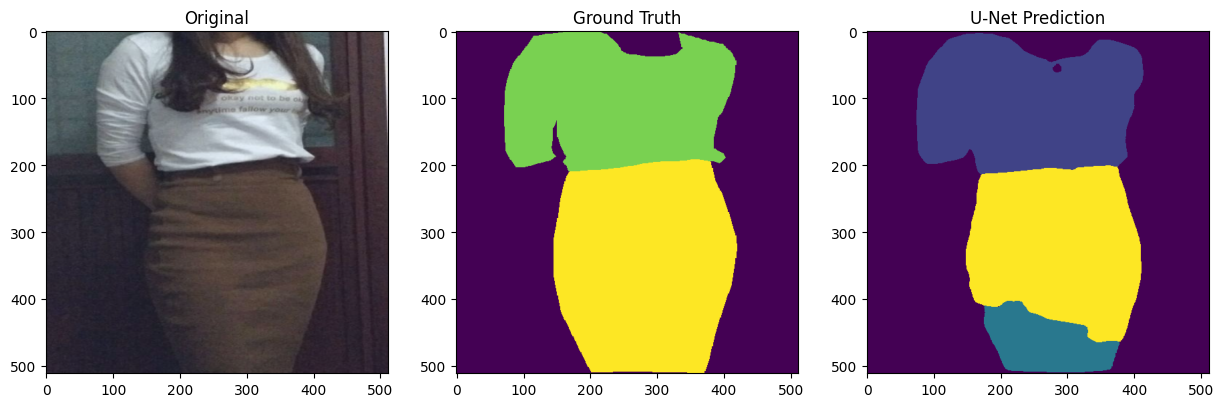

In [7]:
# Show sample prediction
imgs, masks = next(iter(val_loader))
model.eval()
with torch.no_grad():
    preds = model(imgs.to(device)).argmax(dim=1).cpu().numpy()

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(imgs[0].permute(1, 2, 0).numpy() * 0.2 + 0.5); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(masks[0]); plt.title("Ground Truth")
plt.subplot(1, 3, 3); plt.imshow(preds[0]); plt.title("U-Net Prediction")
plt.show()